In [26]:
import pandas as pd
names = [
    "simulations_mixed",
    "simulations_mixed_2",
    #"simulations_mixed_3",
    #"simulations_mixed_4",
    #"simulations_mixed_5",
]
path = "/Users/gustavetriomphe/Documents/XHEC/introduction-to-finance/lending_competition/data/"
df = pd.read_csv(path + names[0] + ".csv")

for name in names[1:]:
    df_temp = pd.read_csv(path + name + ".csv")
    df = pd.concat([df, df_temp])




In [27]:
import sys
import os

# Add parent directory so Python can find src/
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import optimization as op

In [28]:
# plot profit disctributions
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# define bins between 0 and 0.1
bins = np.linspace(0, 0.05, 21)  # 20 bins

# create bin labels for f1 and v1
df['f1_bin'] = pd.cut(df['f1'], bins, include_lowest=True)
df['v1_bin'] = pd.cut(df['v1'], bins, include_lowest=True)



In [29]:
# df_r1, df_r2, df_r3 = op.split_by_m1_rank(df)
# op.plot_profit_distributions(df, df_r1, df_r2, df_r3)

/var/folders/48/xwb303h13cj206r81_rrqr840000gn/T/ipykernel_24874/1827947977.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_profit = df.groupby(['f1_bin', 'v1_bin'])['profits'].mean().unstack()


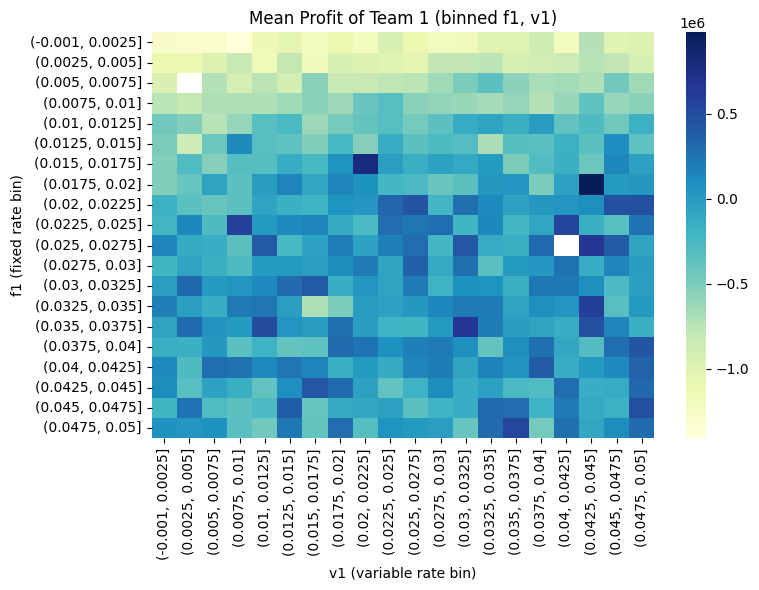

In [30]:
mean_profit = df.groupby(['f1_bin', 'v1_bin'])['profits'].mean().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(mean_profit, cmap='YlGnBu')
plt.title('Mean Profit of Team 1 (binned f1, v1)')
plt.xlabel('v1 (variable rate bin)')
plt.ylabel('f1 (fixed rate bin)')
plt.tight_layout()
plt.show()


/var/folders/48/xwb303h13cj206r81_rrqr840000gn/T/ipykernel_24874/3796872159.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_profit = df.groupby(['f1_bin', 'v1_bin'])['profits'].std().unstack()


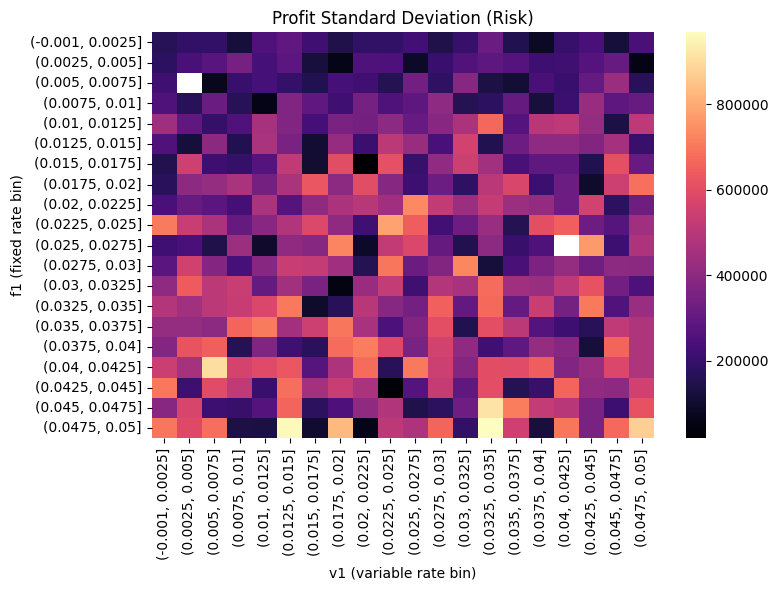

In [31]:
std_profit = df.groupby(['f1_bin', 'v1_bin'])['profits'].std().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(std_profit, cmap='magma')
plt.title('Profit Standard Deviation (Risk)')
plt.xlabel('v1 (variable rate bin)')
plt.ylabel('f1 (fixed rate bin)')
plt.tight_layout()
plt.show()


/var/folders/48/xwb303h13cj206r81_rrqr840000gn/T/ipykernel_24874/556477996.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['f1_bin', 'v1_bin'])['profits']


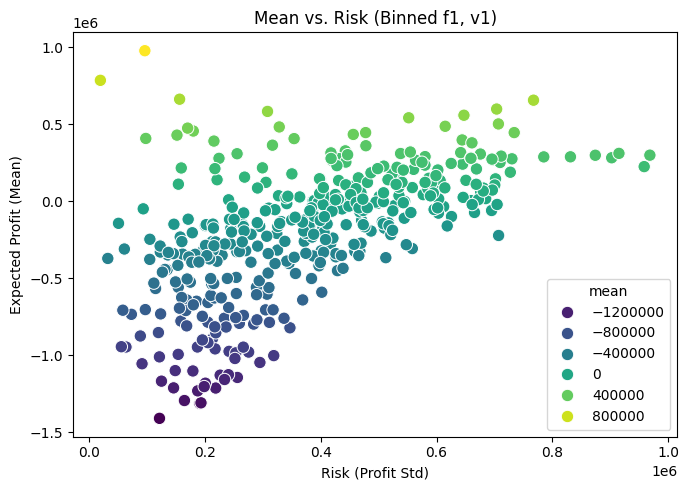

In [32]:
agg = (
    df.groupby(['f1_bin', 'v1_bin'])['profits']
    .agg(['mean', 'std'])
    .reset_index()
)

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=agg,
    x='std', y='mean', hue='mean',
    palette='viridis', s=80
)
plt.title('Mean vs. Risk (Binned f1, v1)')
plt.xlabel('Risk (Profit Std)')
plt.ylabel('Expected Profit (Mean)')
plt.tight_layout()
plt.show()


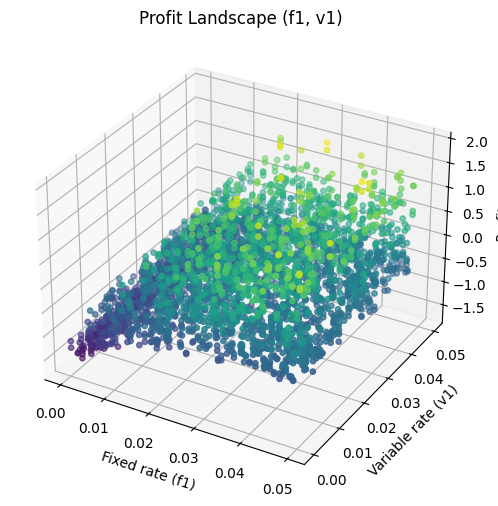

In [33]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['f1'], df['v1'], df['profits'], c=df['profits'], cmap='viridis', s=15)
ax.set_title('Profit Landscape (f1, v1)')
ax.set_xlabel('Fixed rate (f1)')
ax.set_ylabel('Variable rate (v1)')
ax.set_zlabel('Profit')
plt.show()
